Latihan K-Means

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import mode
from sklearn.decomposition import PCA

In [ ]:
# 1. Load Data Iris tanpa target
filepath ="iris.csv"
df = pd.read_csv(filepath, sep=";")
X = df.iloc[:, :-1].values
y_true = LabelEncoder().fit_transform(df.iloc[:, -1].values)  


In [5]:
# 2. Terapkan K-Means dengan K=3 (karena kita tahu ada 3 kelas di data asli)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.labels_

In [ ]:
# 3. Evaluasi hasil clustering
def map_labels(y_pred, y_true):
    labels = np.zeros_like(y_pred)
    for i in range(3):  
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask])[0]
    return labels

y_mapped = map_labels(y_kmeans, y_true)
accuracy = accuracy_score(y_true, y_mapped)
print(f'Akurasi Clustering terhadap label asli: {accuracy:.2f}')

Akurasi Clustering terhadap label asli: 0.89


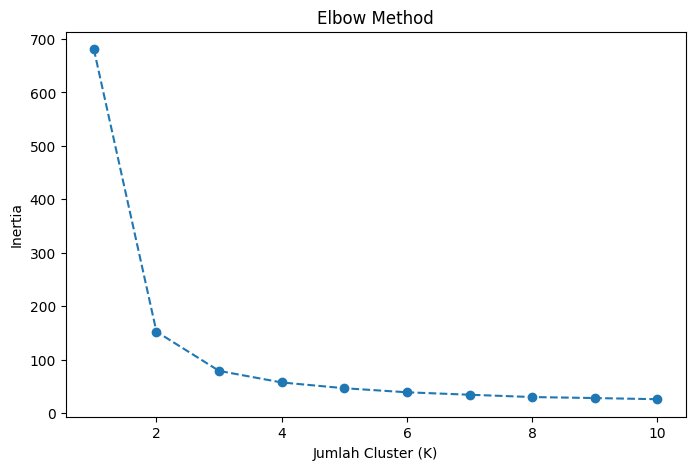

In [7]:
# 4. Menentukan K optimal dengan Elbow Method
inertia = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

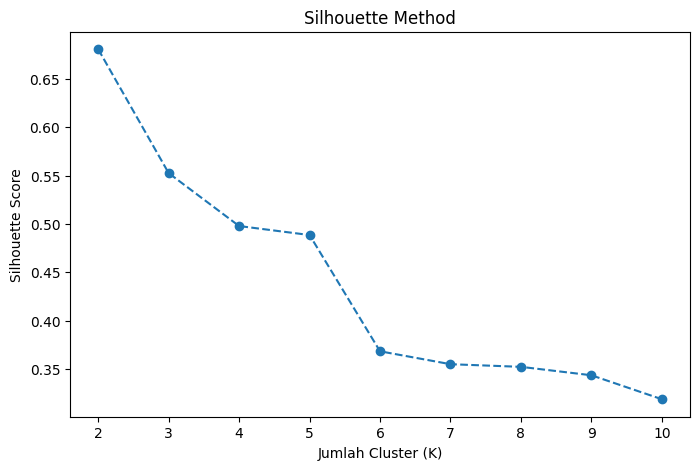

In [ ]:
# 5. Menentukan K optimal dengan Silhouette Score
silhouette_scores = []
for k in range(2, 11): 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

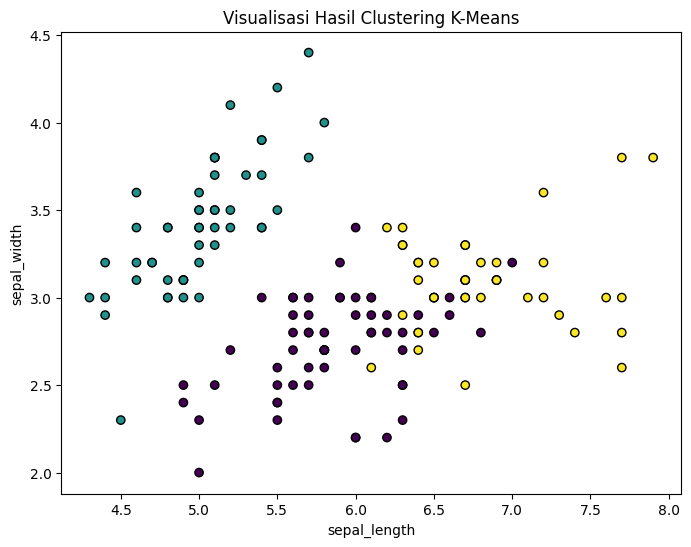

In [10]:
# 6. Visualisasi hasil clustering menggunakan axes
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', edgecolors='k')
ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[1])
ax.set_title('Visualisasi Hasil Clustering K-Means')
plt.show()

Praktikum Dengan data Pribadi

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
filepath ="student_performance_large_dataset.csv"
df = pd.read_csv(filepath, sep=";")
numeric_cols = df.select_dtypes(include=[np.number]).columns
X = df[numeric_cols].values


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

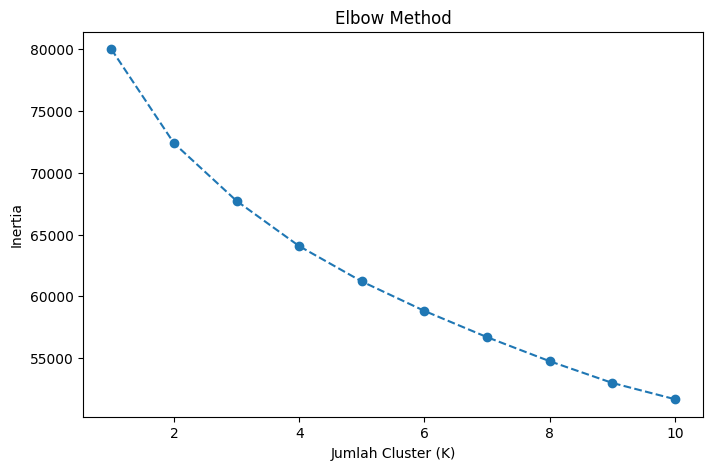

In [21]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

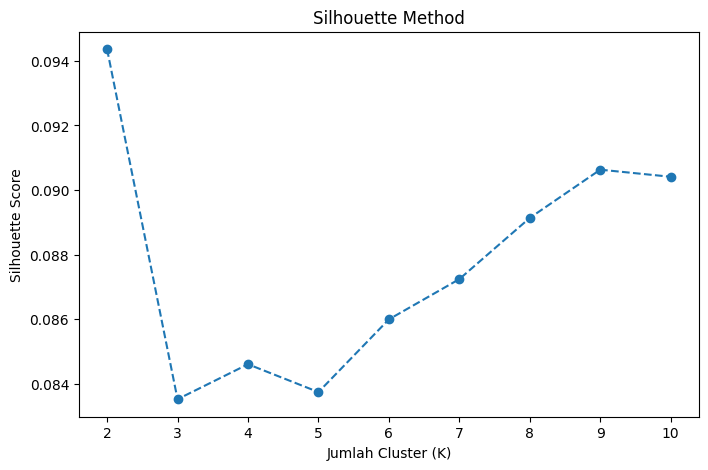

In [23]:
silhouette_scores = []
for k in range(2, 11):  
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

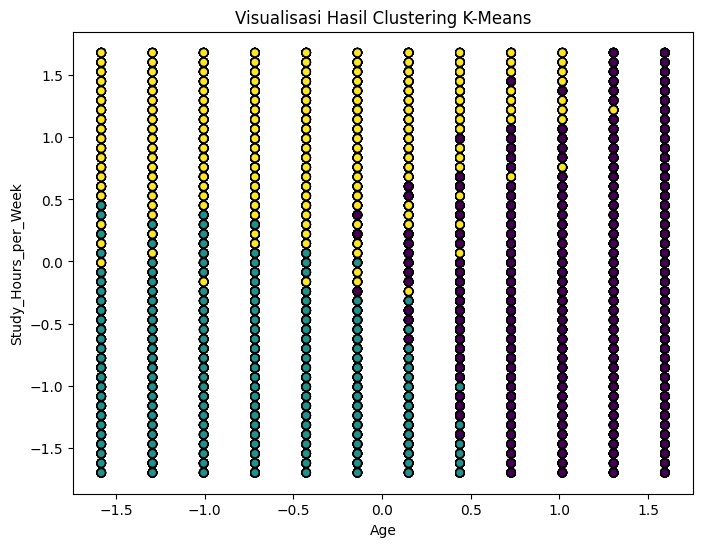

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', edgecolors='k')
ax.set_xlabel(numeric_cols[0])
ax.set_ylabel(numeric_cols[1])
ax.set_title('Visualisasi Hasil Clustering K-Means')
plt.show()